In [1]:
from QLBM import QLBM, collision, InitializeQC
from QLBM_1 import QLBM1, collision1, InitializeQC1
from QLBM_2 import QLBM2, collision2, InitializeQC2
from QLBM_3 import QLBM3, collision3, InitializeQC3
import numpy as np
import matplotlib.pyplot as plt
import qiskit_aer
from qiskit import transpile

In [2]:
# Domain and grid setup
N_POINTS_X, N_POINTS_Y = 16, 16
x_0 = np.arange(N_POINTS_X)
y_0 = np.arange(N_POINTS_Y)
X, Y = np.meshgrid(x_0, y_0)  # Create a 2D grid

# Simulation parameters
TIMESTEPS = 44400
NUMBER_DISCRETE_VELOCITIES = 9  # D2Q9 lattice configuration

In [ ]:
Q = 9

Nx = N_POINTS_X-1
Ny = N_POINTS_Y-1
dx = dy = 1.0
dt = dx
c = dt/dx
f_eq = np.zeros((Nx+1, Ny+1, Q))
f = np.zeros((Nx+1, Ny+1, Q))
Tf_eq = np.zeros((Nx+1, Ny+1, Q))
Tf = np.zeros((Nx+1, Ny+1, Q))
Lx = dx * float(Nx)
Ly = dy * float(Ny)
cs = np.sqrt(c**2/3)

rho_beta = 1e-5
T_l = 2.0
T_r = 1.0
T_star = (T_l+T_r)/2.0
Pr = 0.71
Ra = 1000
Re = np.sqrt(Ra/Pr)
nu = np.sqrt((rho_beta*(T_l-T_r)*Pr*Lx**3)/Ra)
alpha = nu/Pr
alpha_star = nu_star = 1/6*dt
tau_f = 1.0
rho_0 = 1.0
rho = np.zeros((Nx+1, Ny+1))
T = np.zeros((Nx+1, Ny+1))
u = np.zeros((Nx+1, Ny+1, 2))
e = np.array([[0, 0], [1, 0], [0, 1], [-1, 0], [0, -1], [1, 1], [-1, 1], [-1, -1], [1, -1]])
w = np.array([4.0/9, 1.0/9, 1.0/9, 1.0/9, 1.0/9, 1.0/36, 1.0/36, 1.0/36, 1.0/36])

T_n = T.copy() 
u_n = u[:, :, 0].copy()
v_n = u[:, :, 1].copy() 
T_t_x = np.zeros((Nx+1, Ny+1))
T_t_y = np.zeros((Nx+1, Ny+1))
u_t_x = np.zeros((Nx+1, Ny+1))
v_t_x = np.zeros((Nx+1, Ny+1))
u_t_y = np.zeros((Nx+1, Ny+1))
v_t_y = np.zeros((Nx+1, Ny+1))
uT = u[:,:,0].copy()
vT = u[:,:,1].copy()

print(Nx+1)
q_error=[]
c_error=[]
qc_error=[]

0.0004895150661624216 0.7477971822022691 0.49793162648100386
16


In [ ]:
##Initial
rho[:, :] = rho_0
T[:,:] = T_star
T[0,:] = 2.0
T[-1,:] = 1.0

In [5]:
simulator = qiskit_aer.backends.statevector_simulator.StatevectorSimulator()
simulator1 = qiskit_aer.backends.statevector_simulator.StatevectorSimulator()
simulator2 = qiskit_aer.backends.statevector_simulator.StatevectorSimulator()
simulator3 = qiskit_aer.backends.statevector_simulator.StatevectorSimulator()

In [6]:
def possion_u(u_hat,v_hat,T_hat,delta_x):
    vor_u = np.zeros((u_hat.shape[0]+4,u_hat.shape[0]+4))
    vor_v = np.zeros((v_hat.shape[0]+4,v_hat.shape[0]+4))
    vor_T = np.zeros((v_hat.shape[0]+4,v_hat.shape[0]+4))
    vor_u[2:-2,2:-2] = u_hat
    vor_u[1,2:-2] = vor_u[4,2:-2]-3.0*vor_u[3,2:-2] +3.0*vor_u[2,2:-2]
    vor_u[0,2:-2] = 3.0*vor_u[4,2:-2]-8.0*vor_u[3,2:-2] +6.0*vor_u[2,2:-2]
    vor_u[-2,2:-2] = vor_u[-5,2:-2]-3.0*vor_u[-4,2:-2] +3.0*vor_u[-3,2:-2]
    vor_u[-1,2:-2] = 3.0*vor_u[-5,2:-2]-8.0*vor_u[-4,2:-2] +6.0*vor_u[-3,2:-2]
    vor_u[:,1] = vor_u[:,4]-3.0*vor_u[:,3] +3.0*vor_u[:,2]
    vor_u[:,0] = 3.0*vor_u[:,4]-8.0*vor_u[:,3] +6.0*vor_u[:,2]
    vor_u[:,-2] = vor_u[:,-5]-3.0*vor_u[:,-4] +3.0*vor_u[:,-3]
    vor_u[:,-1] = 3.0*vor_u[:,-5]-8.0*vor_u[:,-4] +6.0*vor_u[:,-3]
    """vor_u1 = (-28*vor_u[2:-2,2:-2]-15*(vor_u[1:-3,2:-2] + vor_u[3:-1,2:-2] + vor_u[2:-2,1:-3] + vor_u[2:-2,3:-1]))/(77*delta_x**2) - \
            2.0*(vor_u[3:-1,3:-1] + vor_u[1:-3,3:-1] + vor_u[1:-3,1:-3] + vor_u[3:-1,1:-3])/(77*delta_x**2) + \
            12.0*(vor_u[0:-4,2:-2] + vor_u[4:,2:-2] + vor_u[2:-2,0:-4] + vor_u[2:-2,4:])/(77*delta_x**2)"""
    vor_u1 = (-4*vor_u[2:-2,2:-2]-(vor_u[1:-3,2:-2] + vor_u[3:-1,2:-2] + vor_u[2:-2,1:-3] + vor_u[2:-2,3:-1]))/(3*delta_x**2) + \
            2.0*(vor_u[3:-1,3:-1] + vor_u[1:-3,3:-1] + vor_u[1:-3,1:-3] + vor_u[3:-1,1:-3])/(3*delta_x**2)

    vor_v[2:-2,2:-2] = v_hat
    vor_v[1,2:-2] = vor_v[4,2:-2]-3.0*vor_v[3,2:-2] +3.0*vor_v[2,2:-2]
    vor_v[0,2:-2] = 3.0*vor_v[4,2:-2]-8.0*vor_v[3,2:-2] +6.0*vor_v[2,2:-2]
    vor_v[-2,2:-2] = vor_v[-5,2:-2]-3.0*vor_v[-4,2:-2] +3.0*vor_v[-3,2:-2]
    vor_v[-1,2:-2] = 3.0*vor_v[-5,2:-2]-8.0*vor_v[-4,2:-2] +6.0*vor_v[-3,2:-2]
    vor_v[:,1] = vor_v[:,4]-3.0*vor_v[:,3] +3.0*vor_v[:,2]
    vor_v[:,0] = 3.0*vor_v[:,4]-8.0*vor_v[:,3] +6.0*vor_v[:,2]
    vor_v[:,-2] = vor_v[:,-5]-3.0*vor_v[:,-4] +3.0*vor_v[:,-3]
    vor_v[:,-1] = 3.0*vor_v[:,-5]-8.0*vor_v[:,-4] +6.0*vor_v[:,-3]
    """vor_v1 = (-28*vor_v[2:-2,2:-2]-15*(vor_v[1:-3,2:-2] + vor_v[3:-1,2:-2] + vor_v[2:-2,1:-3] + vor_v[2:-2,3:-1]))/(77*delta_x**2) - \
            2.0*(vor_v[3:-1,3:-1] + vor_v[1:-3,3:-1] + vor_v[1:-3,1:-3] + vor_v[3:-1,1:-3])/(77*delta_x**2) + \
            12.0*(vor_v[0:-4,2:-2] + vor_v[4:,2:-2] + vor_v[2:-2,0:-4] + vor_v[2:-2,4:])/(77*delta_x**2)"""
    vor_v1 = (-4*vor_v[2:-2,2:-2]-(vor_v[1:-3,2:-2] + vor_v[3:-1,2:-2] + vor_v[2:-2,1:-3] + vor_v[2:-2,3:-1]))/(3*delta_x**2) + \
            2.0*(vor_v[3:-1,3:-1] + vor_v[1:-3,3:-1] + vor_v[1:-3,1:-3] + vor_v[3:-1,1:-3])/(3*delta_x**2)

    vor_T[2:-2,2:-2] = T_hat
    vor_T[1,2:-2] = vor_T[4,2:-2]-3.0*vor_T[3,2:-2] +3.0*vor_T[2,2:-2]
    vor_T[0,2:-2] = 3.0*vor_T[4,2:-2]-8.0*vor_T[3,2:-2] +6.0*vor_T[2,2:-2]
    vor_T[-2,2:-2] = vor_T[-5,2:-2]-3.0*vor_T[-4,2:-2] +3.0*vor_T[-3,2:-2]
    vor_T[-1,2:-2] = 3.0*vor_T[-5,2:-2]-8.0*vor_T[-4,2:-2] +6.0*vor_T[-3,2:-2]

    vor_T[:,1] = vor_T[:,3]
    vor_T[:,0] = 4.0*vor_T[:,3]-3.0*vor_T[:,2]
    vor_T[:,-2] = vor_T[:,-4]
    vor_T[:,-1] = 4.0*vor_T[:,-4]-3.0*vor_T[:,-3]
    """vor_T1 = (-28*vor_T[2:-2,2:-2]-15*(vor_T[1:-3,2:-2] + vor_T[3:-1,2:-2] + vor_T[2:-2,1:-3] + vor_T[2:-2,3:-1]))/(77*delta_x**2) - \
            2.0*(vor_T[3:-1,3:-1] + vor_T[1:-3,3:-1] + vor_T[1:-3,1:-3] + vor_T[3:-1,1:-3])/(77*delta_x**2) + \
            12.0*(vor_T[0:-4,2:-2] + vor_T[4:,2:-2] + vor_T[2:-2,0:-4] + vor_T[2:-2,4:])/(77*delta_x**2)"""
    vor_T1 = (-4*vor_T[2:-2,2:-2]-(vor_T[1:-3,2:-2] + vor_T[3:-1,2:-2] + vor_T[2:-2,1:-3] + vor_T[2:-2,3:-1]))/(3*delta_x**2) + \
            2.0*(vor_T[3:-1,3:-1] + vor_T[1:-3,3:-1] + vor_T[1:-3,1:-3] + vor_T[3:-1,1:-3])/(3*delta_x**2)
    

    return vor_u1, vor_v1, vor_T1

# Initialize the quantum LBM scalar field
Psi_qlbm = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm1 = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm2 = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm3 = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm[0, :, :] = rho_0#Psi_init
Psi_qlbm1[0, :, :] = u[:,:,0].copy()#Psi_init
Psi_qlbm2[0, :, :] = u[:,:,1].copy()#Psi_init
Psi_qlbm3[0, :, :] = T.copy()#Psi_init
Psi_qlbm0 = Psi_qlbm[0,:,:].copy()
u_LBM = np.zeros((N_POINTS_X, N_POINTS_Y, 2))
u_LBM[:, :, 0] = Psi_qlbm1[0,:,:]  # Set the x-component of the velocity
u_LBM[:, :, 1] = Psi_qlbm2[0,:,:]  # Set the y-component of the velocity


In [ ]:
# Quantum LBM simulation loop
for t in range(TIMESTEPS):
    u_d, v_d, T_d= possion_u(u[:,:,0],u[:,:,1],T,dx)
    temp = u[:, :, 0] * u[:, :, 0] + u[:, :, 1] * u[:, :, 1]
    f_eq[:, :, 0] = w[0] * rho* (1.0 + 3.0 * (e[0, 0] * u[:, :, 0] + e[0, 1] * u[:, :, 1]) + 4.5 * (e[0, 0] * u[:, :, 0] + e[0, 1] * u[:, :, 1]) ** 2 - 1.5 * temp) + 3.0*w[0]*rho_beta*(T - T_star)*e[0,1]*dt#rho_beta*(T - T_star)#
    f_eq[:, :, 1] = w[1] * rho* (1.0 + 3.0 * (e[1, 0] * u[:, :, 0] + e[1, 1] * u[:, :, 1]) + 4.5 * (e[1, 0] * u[:, :, 0] + e[1, 1] * u[:, :, 1]) ** 2 - 1.5 * temp) + 3.0*w[1]*rho_beta*(T - T_star)*e[1,1]*dt#rho_beta*(T - T_star)#
    f_eq[:, :, 2] = w[2] * rho* (1.0 + 3.0 * (e[2, 0] * u[:, :, 0] + e[2, 1] * u[:, :, 1]) + 4.5 * (e[2, 0] * u[:, :, 0] + e[2, 1] * u[:, :, 1]) ** 2 - 1.5 * temp) + 3.0*w[2]*rho_beta*(T - T_star)*e[2,1]*dt#rho_beta*(T - T_star)#
    f_eq[:, :, 3] = w[3] * rho* (1.0 + 3.0 * (e[3, 0] * u[:, :, 0] + e[3, 1] * u[:, :, 1]) + 4.5 * (e[3, 0] * u[:, :, 0] + e[3, 1] * u[:, :, 1]) ** 2 - 1.5 * temp) + 3.0*w[3]*rho_beta*(T - T_star)*e[3,1]*dt#rho_beta*(T - T_star)#
    f_eq[:, :, 4] = w[4] * rho* (1.0 + 3.0 * (e[4, 0] * u[:, :, 0] + e[4, 1] * u[:, :, 1]) + 4.5 * (e[4, 0] * u[:, :, 0] + e[4, 1] * u[:, :, 1]) ** 2 - 1.5 * temp) + 3.0*w[4]*rho_beta*(T - T_star)*e[4,1]*dt#rho_beta*(T - T_star)#
    f_eq[:, :, 5] = w[5] * rho* (1.0 + 3.0 * (e[5, 0] * u[:, :, 0] + e[5, 1] * u[:, :, 1]) + 4.5 * (e[5, 0] * u[:, :, 0] + e[5, 1] * u[:, :, 1]) ** 2 - 1.5 * temp) + 3.0*w[5]*rho_beta*(T - T_star)*e[5,1]*dt#rho_beta*(T - T_star)#
    f_eq[:, :, 6] = w[6] * rho* (1.0 + 3.0 * (e[6, 0] * u[:, :, 0] + e[6, 1] * u[:, :, 1]) + 4.5 * (e[6, 0] * u[:, :, 0] + e[6, 1] * u[:, :, 1]) ** 2 - 1.5 * temp) + 3.0*w[6]*rho_beta*(T - T_star)*e[6,1]*dt#rho_beta*(T - T_star)#
    f_eq[:, :, 7] = w[7] * rho* (1.0 + 3.0 * (e[7, 0] * u[:, :, 0] + e[7, 1] * u[:, :, 1]) + 4.5 * (e[7, 0] * u[:, :, 0] + e[7, 1] * u[:, :, 1]) ** 2 - 1.5 * temp) + 3.0*w[7]*rho_beta*(T - T_star)*e[7,1]*dt#rho_beta*(T - T_star)#
    f_eq[:, :, 8] = w[8] * rho* (1.0 + 3.0 * (e[8, 0] * u[:, :, 0] + e[8, 1] * u[:, :, 1]) + 4.5 * (e[8, 0] * u[:, :, 0] + e[8, 1] * u[:, :, 1]) ** 2 - 1.5 * temp) + 3.0*w[8]*rho_beta*(T - T_star)*e[8,1]*dt#rho_beta*(T - T_star)#
    
    Tf_eq[:, :, 0] = w[0] * T* (1.0 + 3.0 * (e[0, 0] * u[:, :, 0] + e[0, 1] * u[:, :, 1]) + 4.5 * (e[0, 0] * u[:, :, 0] + e[0, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    Tf_eq[:, :, 1] = w[1] * T* (1.0 + 3.0 * (e[1, 0] * u[:, :, 0] + e[1, 1] * u[:, :, 1]) + 4.5 * (e[1, 0] * u[:, :, 0] + e[1, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    Tf_eq[:, :, 2] = w[2] * T* (1.0 + 3.0 * (e[2, 0] * u[:, :, 0] + e[2, 1] * u[:, :, 1]) + 4.5 * (e[2, 0] * u[:, :, 0] + e[2, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    Tf_eq[:, :, 3] = w[3] * T* (1.0 + 3.0 * (e[3, 0] * u[:, :, 0] + e[3, 1] * u[:, :, 1]) + 4.5 * (e[3, 0] * u[:, :, 0] + e[3, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    Tf_eq[:, :, 4] = w[4] * T* (1.0 + 3.0 * (e[4, 0] * u[:, :, 0] + e[4, 1] * u[:, :, 1]) + 4.5 * (e[4, 0] * u[:, :, 0] + e[4, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    Tf_eq[:, :, 5] = w[5] * T* (1.0 + 3.0 * (e[5, 0] * u[:, :, 0] + e[5, 1] * u[:, :, 1]) + 4.5 * (e[5, 0] * u[:, :, 0] + e[5, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    Tf_eq[:, :, 6] = w[6] * T* (1.0 + 3.0 * (e[6, 0] * u[:, :, 0] + e[6, 1] * u[:, :, 1]) + 4.5 * (e[6, 0] * u[:, :, 0] + e[6, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    Tf_eq[:, :, 7] = w[7] * T* (1.0 + 3.0 * (e[7, 0] * u[:, :, 0] + e[7, 1] * u[:, :, 1]) + 4.5 * (e[7, 0] * u[:, :, 0] + e[7, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    Tf_eq[:, :, 8] = w[8] * T* (1.0 + 3.0 * (e[8, 0] * u[:, :, 0] + e[8, 1] * u[:, :, 1]) + 4.5 * (e[8, 0] * u[:, :, 0] + e[8, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    
    f[:, :, 0] = f[:, :, 0] - (f[:, :, 0] - f_eq[:, :, 0]) / tau_f
    f[:, :, 1] = f[:, :, 1] - (f[:, :, 1] - f_eq[:, :, 1]) / tau_f
    f[:, :, 2] = f[:, :, 2] - (f[:, :, 2] - f_eq[:, :, 2]) / tau_f
    f[:, :, 3] = f[:, :, 3] - (f[:, :, 3] - f_eq[:, :, 3]) / tau_f
    f[:, :, 4] = f[:, :, 4] - (f[:, :, 4] - f_eq[:, :, 4]) / tau_f
    f[:, :, 5] = f[:, :, 5] - (f[:, :, 5] - f_eq[:, :, 5]) / tau_f
    f[:, :, 6] = f[:, :, 6] - (f[:, :, 6] - f_eq[:, :, 6]) / tau_f
    f[:, :, 7] = f[:, :, 7] - (f[:, :, 7] - f_eq[:, :, 7]) / tau_f
    f[:, :, 8] = f[:, :, 8] - (f[:, :, 8] - f_eq[:, :, 8]) / tau_f

    Tf[:, :, 0] = Tf[:, :, 0] - (Tf[:, :, 0] - Tf_eq[:, :, 0]) / tau_f
    Tf[:, :, 1] = Tf[:, :, 1] - (Tf[:, :, 1] - Tf_eq[:, :, 1]) / tau_f
    Tf[:, :, 2] = Tf[:, :, 2] - (Tf[:, :, 2] - Tf_eq[:, :, 2]) / tau_f
    Tf[:, :, 3] = Tf[:, :, 3] - (Tf[:, :, 3] - Tf_eq[:, :, 3]) / tau_f
    Tf[:, :, 4] = Tf[:, :, 4] - (Tf[:, :, 4] - Tf_eq[:, :, 4]) / tau_f
    Tf[:, :, 5] = Tf[:, :, 5] - (Tf[:, :, 5] - Tf_eq[:, :, 5]) / tau_f
    Tf[:, :, 6] = Tf[:, :, 6] - (Tf[:, :, 6] - Tf_eq[:, :, 6]) / tau_f
    Tf[:, :, 7] = Tf[:, :, 7] - (Tf[:, :, 7] - Tf_eq[:, :, 7]) / tau_f
    Tf[:, :, 8] = Tf[:, :, 8] - (Tf[:, :, 8] - Tf_eq[:, :, 8]) / tau_f

    ##streaming
    for i in range(9):
        f[:,:,i] = np.roll(f[:,:,i], shift=e[i,0], axis=0)
        f[:,:,i] = np.roll(f[:,:,i], shift=e[i,1], axis=1)
        Tf[:,:,i] = np.roll(Tf[:,:,i], shift=e[i,0], axis=0)
        Tf[:,:,i] = np.roll(Tf[:,:,i], shift=e[i,1], axis=1)
    
    rho = f[:, :, 0] + f[:, :, 1] +f[:, :, 2]+f[:, :, 3]+f[:, :, 4]+f[:, :, 5]+f[:, :, 6]+f[:, :, 7]+f[:, :, 8]
    u[:, :, 0] = (f[:, :, 1] - f[:, :, 3] + f[:, :, 5] - f[:, :, 6] - f[:, :, 7] + f[:, :, 8]) / rho
    u[:, :, 1] = (f[:, :, 2] - f[:, :, 4] + f[:, :, 5] + f[:, :, 6] - f[:, :, 7] - f[:, :, 8]) / rho
    T = Tf[:, :, 0] + Tf[:, :, 1] +Tf[:, :, 2]+Tf[:, :, 3]+Tf[:, :, 4]+Tf[:, :, 5]+Tf[:, :, 6]+Tf[:, :, 7]+Tf[:, :, 8]
    T = T + dt*(alpha-alpha_star)*T_d
    T[:, 0] = 4/3*T[:, 1] - 1/3*T[:, 2]
    T[:, Ny] = 4/3*T[:, Ny-1] - 1/3*T[:, Ny-2]
    T[0, :] = 2.0
    T[Ny, :] = 1.0
    
    u[:, 0, 0] = u[0, :, 0] = u[Ny, :, 0] = u[:, Ny, 0] = 0.0
    u[:, 0, 1] = u[0, :, 1] = u[Ny, :, 1] = u[:, Ny, 1] = 0.0

    rho[:, 0] = 4.0*rho[:,1]-6.0*rho[:,2] + 4.0*rho[:,3] - rho[:,4]
    rho[0, :] = 4.0*rho[1,:] - 6.0*rho[2,:] + 4.0*rho[3,:] - rho[4,:]
    rho[Ny, :] = 4.0*rho[Ny-1,:] - 6.0*rho[Ny-2,:] + 4.0*rho[Ny-3,:] - rho[Ny-4,:]
    rho[:, Ny] = 4.0*rho[:,Ny-1] - 6.0*rho[:,Ny-2] + 4.0*rho[:,Ny-3] - rho[:,Ny-4]
    u[:, :, 0] = u[:, :, 0] + dt*(nu-nu_star)*u_d
    u[:, :, 1] = u[:, :, 1] + dt*(nu-nu_star)*v_d
    u[:, Ny, 0] = u[:, 0, 0] = u[0, :, 0] = u[Ny, :, 0] = 0.0
    u[:, 0, 1] = u[0, :, 1] = u[Ny, :, 1] = u[:, Ny, 1] = 0.0
    
    u_dq, v_dq, T_dq= possion_u(Psi_qlbm1[t, :, :],Psi_qlbm2[t, :, :],Psi_qlbm3[t, :, :],dx)
    # Create and run the quantum circuit for LBM, rho
    qc = QLBM(density_field=Psi_qlbm[t, :, :], T_field=Psi_qlbm3[t,:,:], velocity_field=u_LBM, nu_=nu, number_velocities=NUMBER_DISCRETE_VELOCITIES)
    compiled_circuit = transpile(qc, simulator)
    result = simulator.run(compiled_circuit).result()
    
    # Process the quantum statevector to update Psi_qlbm
    statevector = np.array(result.get_statevector())
    real_part_statevector = np.real(statevector[:N_POINTS_X * N_POINTS_Y])
    real_part_statevector_reshaped = np.reshape(real_part_statevector, (N_POINTS_X, N_POINTS_Y), order='F')
    
    # Normalize and update the scalar field for the next timestep
    Psi_qlbm[t + 1, :, :] = real_part_statevector_reshaped * np.linalg.norm(Psi_qlbm[t, :, :].flatten()) * 4
    Psi_qlbm[t + 1,:, 0] = 4.0*Psi_qlbm[t + 1,:,1] - 6.0*Psi_qlbm[t + 1,:,2] + 4.0*Psi_qlbm[t + 1,:,3] - Psi_qlbm[t + 1,:,4]
    Psi_qlbm[t + 1,0, :] = 4.0*Psi_qlbm[t + 1,1, :] - 6.0*Psi_qlbm[t + 1,2, :] + 4.0*Psi_qlbm[t + 1,3, :] - Psi_qlbm[t + 1,4, :]
    Psi_qlbm[t + 1,Ny, :] = 4.0*Psi_qlbm[t + 1,Ny-1, :] - 6.0*Psi_qlbm[t + 1,Ny-2, :] + 4.0*Psi_qlbm[t + 1,Ny-3, :] - Psi_qlbm[t + 1,Ny-4, :]
    Psi_qlbm[t + 1,:, Ny] = 4.0*Psi_qlbm[t + 1,:,Ny-1] - 6.0*Psi_qlbm[t + 1,:,Ny-2] + 4.0*Psi_qlbm[t + 1,:,Ny-3] - Psi_qlbm[t + 1,:,Ny-4]

    # Create and run the quantum circuit for LBM, u
    qc1 = QLBM1(density_field=Psi_qlbm0, T_field=Psi_qlbm3[t,:,:], velocity_field=u_LBM, nu_=nu, number_velocities=NUMBER_DISCRETE_VELOCITIES)
    compiled_circuit1 = transpile(qc1, simulator1)
    result1 = simulator1.run(compiled_circuit1).result()
    
    # Process the quantum statevector to update Psi_qlbm
    statevector1 = np.array(result1.get_statevector())
    real_part_statevector1 = np.real(statevector1[:N_POINTS_X * N_POINTS_Y])
    real_part_statevector_reshaped1 = np.reshape(real_part_statevector1, (N_POINTS_X, N_POINTS_Y), order='F')
    
    # Normalize and update the scalar field for the next timestep
    Psi_qlbm1[t + 1, :, :] = real_part_statevector_reshaped1 * np.linalg.norm(Psi_qlbm0.flatten()) * 4 / Psi_qlbm0
    Psi_qlbm1[t + 1,:, 0] = Psi_qlbm1[t + 1,0, :] = Psi_qlbm1[t + 1,Ny, :] = Psi_qlbm1[t + 1,:, Ny] = 0.0

    # Create and run the quantum circuit for LBM, u
    qc2 = QLBM2(density_field=Psi_qlbm0, T_field=Psi_qlbm3[t,:,:], velocity_field=u_LBM, nu_=nu, number_velocities=NUMBER_DISCRETE_VELOCITIES)
    compiled_circuit2 = transpile(qc2, simulator2)
    result2 = simulator2.run(compiled_circuit2).result()
    
    # Process the quantum statevector to update Psi_qlbm
    statevector2 = np.array(result2.get_statevector())
    real_part_statevector2 = np.real(statevector2[:N_POINTS_X * N_POINTS_Y])
    real_part_statevector_reshaped2 = np.reshape(real_part_statevector2, (N_POINTS_X, N_POINTS_Y), order='F')
    
    # Normalize and update the scalar field for the next timestep
    Psi_qlbm2[t + 1, :, :] = real_part_statevector_reshaped2 * np.linalg.norm(Psi_qlbm0.flatten()) * 4 / Psi_qlbm0
    
    Psi_qlbm2[t + 1,:, 0] = Psi_qlbm2[t + 1,0, :] = Psi_qlbm2[t + 1,Ny, :] = Psi_qlbm2[t + 1,:, Ny] = 0.0 

    # Create and run the quantum circuit for LBM, u
    qc3 = QLBM3(density_field=Psi_qlbm3[t,:,:], velocity_field=u_LBM, nu_=alpha, number_velocities=NUMBER_DISCRETE_VELOCITIES)
    compiled_circuit3 = transpile(qc3, simulator3)
    result3 = simulator3.run(compiled_circuit3).result()
    
    # Process the quantum statevector to update Psi_qlbm
    statevector3 = np.array(result3.get_statevector())
    real_part_statevector3 = np.real(statevector3[:N_POINTS_X * N_POINTS_Y])
    real_part_statevector_reshaped3 = np.reshape(real_part_statevector3, (N_POINTS_X, N_POINTS_Y), order='F')
    
    # Normalize and update the scalar field for the next timestep
    Psi_qlbm3[t + 1, :, :] = real_part_statevector_reshaped3 * np.linalg.norm(Psi_qlbm3[t,:,:].flatten()) * 4 
    
    Psi_qlbm1[t + 1, :, :] = Psi_qlbm1[t + 1, :, :] +dt*(nu-nu_star)*u_dq  
    Psi_qlbm2[t + 1, :, :] = Psi_qlbm2[t + 1, :, :] +dt*(nu-nu_star)*v_dq  
    Psi_qlbm3[t + 1, :, :] = Psi_qlbm3[t + 1, :, :] +dt*(alpha-alpha_star)*T_dq
    Psi_qlbm1[t + 1,:, 0] = Psi_qlbm1[t + 1,0, :] = Psi_qlbm1[t + 1,Ny, :] = Psi_qlbm1[t + 1,:, Ny] = 0.0
    Psi_qlbm2[t + 1,:, 0] = Psi_qlbm2[t + 1,0, :] = Psi_qlbm2[t + 1,Ny, :] = Psi_qlbm2[t + 1,:, Ny] = 0.0 

    Psi_qlbm3[t + 1,:, 0] = 4/3*Psi_qlbm3[t + 1,:, 1] -1/3*Psi_qlbm3[t + 1,:, 2]
    Psi_qlbm3[t + 1,0, :] = 2.0
    Psi_qlbm3[t + 1,Ny, :] = 1.0
    Psi_qlbm3[t + 1,:, Ny] = 4/3*Psi_qlbm3[t + 1,:, Ny-1] -1/3*Psi_qlbm3[t + 1,:, Ny-2]
    Psi_qlbm0 = Psi_qlbm[t + 1, :, :].copy()
    
    error = np.sum(np.sqrt((T_n[1:-1,1:-1]-T[1:-1,1:-1])**2+(u_n[1:-1,1:-1]-u[1:-1,1:-1, 0])**2+(v_n[1:-1,1:-1]-u[1:-1,1:-1, 1])**2))/np.sum(np.sqrt(T[1:-1,1:-1]**2+u[1:-1,1:-1, 0]**2+u[1:-1,1:-1, 1]**2))
    T_n = T[:, :].copy() 
    u_n = u[:, :, 0].copy() 
    v_n = u[:, :, 1].copy()
    
    u_LBM[:,:,0] = Psi_qlbm1[t + 1, :, :]
    u_LBM[:,:,1] = Psi_qlbm2[t + 1, :, :]
    error1 = np.sum(np.sqrt((Psi_qlbm1[t + 1, :, :]-Psi_qlbm1[t, :, :])**2+(Psi_qlbm2[t + 1, :, :]-Psi_qlbm2[t, :, :])**2+(Psi_qlbm3[t + 1, :, :]-Psi_qlbm3[t, :, :])**2))/np.sum(np.sqrt(Psi_qlbm1[t + 1, :, :]**2+Psi_qlbm2[t + 1, :, :]**2+Psi_qlbm3[t + 1, :, :]**2))
    error2 = np.sum(np.sqrt((Psi_qlbm1[t + 1, :, :]-u_n)**2+(Psi_qlbm2[t + 1, :, :]-v_n)**2+(Psi_qlbm3[t + 1, :, :]-T_n)**2))/np.sum(np.sqrt(u_n**2+v_n**2+T_n**2))
    
    q_error.append(error1)
    c_error.append(error)
    qc_error.append(error2)
    if error < 1e-7 and error1 < 1e-7:
        break
    print(t, error, error1, error2)

0 1.0 2.87274834346808e-05 5.3423244475779805e-15
1 3.280895918155047e-05 2.870780983299764e-05 1.3464388682908935e-14
2 3.278752224431494e-05 2.8689497743425092e-05 3.0008993388912555e-14
3 3.2768462740014e-05 2.8673734674610716e-05 6.580776032099375e-14
4 3.275372529399179e-05 2.8662193609343358e-05 1.3693681303955188e-13
5 3.2744510792871735e-05 2.8655767819677487e-05 2.592849959197598e-13
6 3.274094455325146e-05 2.8654369827479086e-05 4.382126516932577e-13
7 3.2742318124911816e-05 2.865712121898242e-05 6.589189229677889e-13
8 3.27474885316908e-05 2.8662721797732977e-05 9.184345367847088e-13
9 3.275467770278287e-05 2.8669255929589288e-05 1.2138677435294106e-12
10 3.276135020152872e-05 2.867415920839803e-05 1.5540606020844863e-12
11 3.2764411834921566e-05 2.8674514883273275e-05 1.934269356258988e-12
12 3.2760613610236e-05 2.866758534999737e-05 2.3516362030449347e-12
13 3.274725684304836e-05 2.86514910088194e-05 2.7693622436823183e-12
14 3.2723075980328615e-05 2.8625855979804572e-05 3

In [ ]:
print(t, error, error1, error2)

T_t_x1 = np.zeros_like(T)
T1 = T-1
T_t_x1[1:-1,:] = (T1[2:, :] - T1[:-2, :])/(2.0*dx)
T_t_x1[0,:] = (3.0*T1[0, :] - 4.0*T1[1, :] + T1[2, :])/(2.0*dx)
T_t_x1[-1,:] = (3.0*T1[-1, :] - 4.0*T1[-2, :] + T1[-3, :])/(2.0*dx)
Nu = np.sum(u[:,:,0]*(T1)-alpha*T_t_x1)/(Lx*alpha)

T_t_x1q = np.zeros_like(Psi_qlbm3[t + 1, :, :])
T1q = Psi_qlbm3[t + 1, :, :]-1
T_t_x1q[1:-1,:] = (T1q[2:, :] - T1q[:-2, :])/(2.0*dx)
T_t_x1q[0,:] = (3.0*T1q[0, :] - 4.0*T1q[1, :] + T1q[2, :])/(2.0*dx)
T_t_x1q[-1,:] = (3.0*T1q[-1, :] - 4.0*T1q[-2, :] + T1q[-3, :])/(2.0*dx)
Nuq = np.sum(Psi_qlbm1[t + 1, :,:]*(T1q)-alpha*T_t_x1q)/(Lx*alpha)

print(alpha,Nu,Nuq)

27940 9.998407957959679e-08 9.427823872444699e-08 2.0858460251456287e-06
0.0006894578396653826 1.7640413936740014 1.7640122783395669


In [ ]:
np.savetxt("Ra=1000_16\QLBM_u"+str(t)+".csv",Psi_qlbm1[t+1,:,:],delimiter=",")
np.savetxt("Ra=1000_16\QLBM_v"+str(t)+".csv",Psi_qlbm2[t+1,:,:],delimiter=",")
np.savetxt("Ra=1000_16\QLBM_rho"+str(t)+".csv",Psi_qlbm[t+1,:,:],delimiter=",")
np.savetxt("Ra=1000_16\QLBM_T"+str(t)+".csv",Psi_qlbm3[t+1,:,:],delimiter=",")
np.savetxt("Ra=1000_16\CLBM_u"+str(t)+".csv",u[:,:,0],delimiter=",")
np.savetxt("Ra=1000_16\CLBM_v"+str(t)+".csv",u[:,:,1],delimiter=",")
np.savetxt("Ra=1000_16\CLBM_rho"+str(t)+".csv",rho,delimiter=",")
np.savetxt("Ra=1000_16\CLBM_T"+str(t)+".csv",T,delimiter=",")
np.savetxt("Ra=1000_16\QLBM_error.csv",q_error,delimiter=",")
np.savetxt("Ra=1000_16\CLBM_error.csv",c_error,delimiter=",")
np.savetxt("Ra=1000_16\QLBM_CLBM_error.csv",qc_error,delimiter=",")

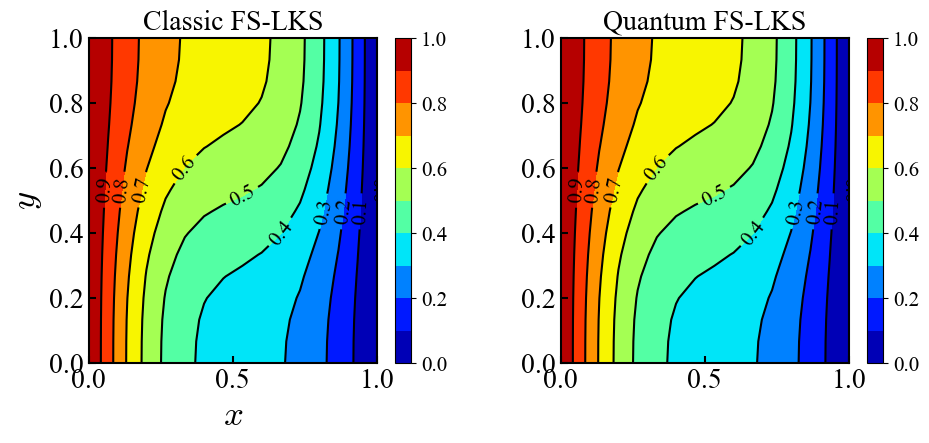

In [ ]:
import matplotlib
font = {'family': 'Times New Roman',}
font1 = {'family': 'Times New Roman','style': 'italic',}
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['mathtext.fontset'] = 'cm'

fig = plt.figure(figsize=(20, 5))
ax1 = plt.axes([0.056, 0.2, 0.18, 0.65])
ax01=plt.contourf(X/Lx,Y/Lx,(T-1).T, 11,cmap='jet')
ax001 = plt.colorbar(ax01)
ax001.ax.tick_params(labelsize=15)
CS=plt.contour(X/Lx,Y/Lx,(T-1).T,11,colors='k',linestyles='-',zorder=10)
ax1.clabel(CS, inline=True, fontsize=15)
ax1.set_xlabel('$x$', size = 25,fontdict = font1)
ax1.set_ylabel('$y$', size = 25,fontdict = font1)    
ax1.set_title('Classic FS-LBM', fontsize = 20,fontdict = font)
ax1.tick_params(labelsize=20)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax1.tick_params(axis="both", which="major", direction="in", width=1.5, length=5)

ax2 = plt.axes([0.292, 0.2, 0.18, 0.65])
ax02=plt.contourf(X/Lx,Y/Lx,(Psi_qlbm3[t + 1, :, :]-1).T, 11,cmap='jet')
ax002 = plt.colorbar(ax02)
ax002.ax.tick_params(labelsize=15)
CS1=plt.contour(X/Lx,Y/Lx,(Psi_qlbm3[t + 1, :, :]-1).T,11,colors='k',linestyles='-',zorder=10)
ax2.clabel(CS1, inline=True, fontsize=15)
ax2.set_title('Quantum FS-LBM', fontsize = 20,fontdict = font)
ax2.tick_params(labelsize=20)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax2.tick_params(axis="both", which="major", direction="in", width=1.5, length=5)

#plt.savefig('Ra_1000_T.jpg', format='jpg',bbox_inches='tight', dpi=200)
plt.show()

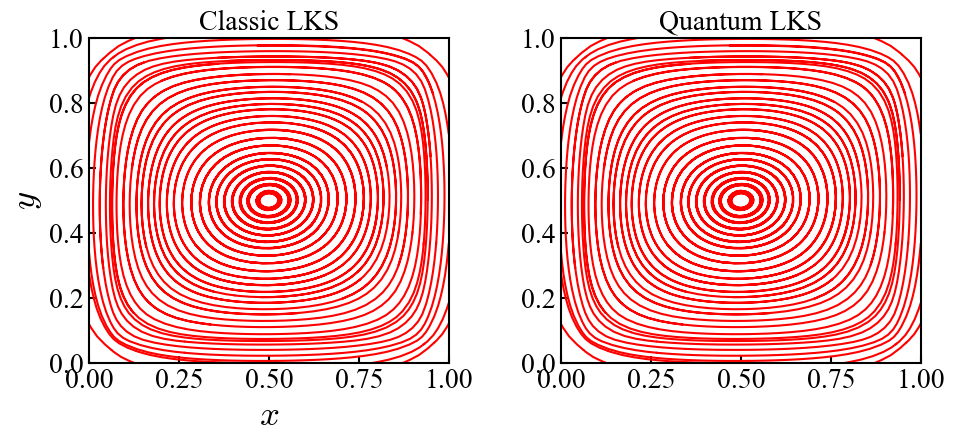

In [ ]:
import matplotlib
font = {'family': 'Times New Roman',}
font1 = {'family': 'Times New Roman','style': 'italic',}
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['mathtext.fontset'] = 'cm'

fig = plt.figure(figsize=(20, 5))
ax1 = plt.axes([0.056, 0.2, 0.18, 0.65])

plt.streamplot(X/Lx,Y/Lx,u[:,:,0].T,u[:,:,1].T,density=1,arrowstyle='-',color='r',broken_streamlines=False)
ax1.set_xlabel('$x$', size = 25,fontdict = font1)
ax1.set_ylabel('$y$', size = 25,fontdict = font1)    
ax1.set_title('Classic FS-LBM', fontsize = 20,fontdict = font)
ax1.tick_params(labelsize=20)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax1.tick_params(axis="both", which="major", direction="in", width=1.5, length=5)

ax2 = plt.axes([0.292, 0.2, 0.18, 0.65])
plt.streamplot(X/Lx,Y/Lx,Psi_qlbm1[t+1,:,:].T,Psi_qlbm2[t+1,:,:].T,density=1,arrowstyle='-',color='r',broken_streamlines=False)
ax2.set_title('Quantum FS-LBM', fontsize = 20,fontdict = font)
ax2.tick_params(labelsize=20)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax2.tick_params(axis="both", which="major", direction="in", width=1.5, length=5)

#plt.savefig('streamline_1000_16.jpg', format='jpg',bbox_inches='tight', dpi=200)
plt.show()

